# Prédiction de la variation journalière des prix à terme de l'électricité
### Master 2 IEF – Data Science 2025/2026
---

## 1. Problématique et approche

### Contexte

Ce projet s'inscrit dans le cadre d'un challenge de prédiction des prix de marché de l'électricité en France (FR) et en Allemagne (DE). La variable cible `TARGET` correspond à la **variation journalière des prix à terme d'électricité** (prix observé en J vs J-1 pour un produit de livraison 24h).

Les prix spot de l'électricité sont déterminés par l'équilibre offre/demande selon le principe du **merit order** : le prix reflète le coût marginal de la dernière centrale appelée pour équilibrer le réseau. Plusieurs facteurs structurels influencent cette dynamique :

- **Le mix de production** : en France, dominé par le nucléaire (~65-70%) ; en Allemagne, par les ENR (~50%) et les centrales thermiques (charbon + gaz ~50%). Ces différences impliquent des comportements de prix fondamentalement distincts.
- **Les conditions météorologiques** : la production solaire et éolienne est directement liée aux conditions climatiques. Par temps sans vent et sans soleil, l'Allemagne dépend massivement du gaz et du charbon, ce qui fait monter les prix.
- **Les prix des matières premières** : le gaz, le charbon et les droits carbone (CO2) fixent le coût marginal des centrales thermiques. La crise gazière de 2022 illustre à quel point ces variables peuvent faire s'envoler les prix spot.
- **Les échanges transfrontaliers** : France et Allemagne sont fortement interconnectées, et leurs échanges électriques influencent la formation des prix des deux côtés.

### Approche

Il s'agit d'un **problème de régression** : on cherche à prédire une variation de prix (variable continue). La métrique d'évaluation imposée par le challenge est le **coefficient de corrélation de Spearman**, qui mesure la capacité du modèle à bien ordonner les observations (ranking), ce qui est particulièrement pertinent pour les stratégies de trading.

Étant donné les différences structurelles entre les deux pays, nous construisons **deux modèles séparés** : un pour la France, un pour l'Allemagne.

Les étapes suivies :
1. Exploration et préparation des données
2. Construction des features
3. Modèle de référence (régression linéaire Ridge)
4. Modèle non supervisé (K-Means) utilisé comme feature engineering
5. Modèle ensembliste (Random Forest + Gradient Boosting) avec optimisation
6. Interprétabilité (feature importance, SHAP)
7. Comparaison des modèles

## 2. Imports et chargement des données

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr

from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import make_scorer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
import os
import json
import shap

# reproductibilité
SEED = 42
np.random.seed(SEED)

# Directories
ROOT_DIR = os.path.abspath("")
DATA_DIR = os.path.join(ROOT_DIR, "data/")


# Variable globale (hypothèses d'émissions de CO2 pour les énergies fossiles et de l'efficacité de conversion en électricité)

GAS_EFFICIENCY = 0.5 # il faut 0,5 MWh de gaz pour produire 1 MWh d'électricité
GAS_EMISSION_FACTOR = 0.4 # émission de 0,4 tonne de CO2 par MWh de gaz brûlé 

COAL_EFFICIENCY = 0.5 # il faut 0,5 tonne de charbon pour produire 1 MWh d'électricité
COAL_EMISSION_FACTOR = 1 # émission d'une tonne de CO2 par tonne de charbon brûlée

In [2]:
x_train = pd.read_csv(DATA_DIR + "X_train.csv")
y_train = pd.read_csv(DATA_DIR + "y_train.csv")
x_test = pd.read_csv(DATA_DIR + "X_test.csv")

print(f'X_train : {x_train.shape}')
print(f'y_train : {y_train.shape}')
print(f'X_test  : {x_test.shape}')

X_train : (1494, 35)
y_train : (1494, 2)
X_test  : (654, 35)


In [3]:
# on fusionne x_train et y_train sur l'ID pour avoir un seul DataFrame de travail
df = x_train.merge(y_train, on='ID')
print(df['COUNTRY'].value_counts())
df.head()

COUNTRY
FR    851
DE    643
Name: count, dtype: int64


,ID,DAY_ID,COUNTRY,DE_CONSUMPTION,FR_CONSUMPTION,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,FR_NET_EXPORT,DE_NET_IMPORT,...,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP,GAS_RET,COAL_RET,CARBON_RET,TARGET
0,1054,206,FR,0.210099,-0.427458,-0.606523,0.606523,NaN,0.692860,NaN,...,-0.172680,-0.556356,-0.790823,-0.283160,-1.069070,-0.063404,0.339041,0.124552,-0.002445,0.028313
1,2049,501,FR,-0.022399,-1.003452,-0.022063,0.022063,-0.573520,-1.130838,0.573520,...,-1.240300,-0.770457,1.522331,0.828412,0.437419,1.831241,-0.659091,0.047114,-0.490365,-0.112516
2,1924,687,FR,1.395035,1.978665,1.021305,-1.021305,-0.622021,-1.682587,0.622021,...,-0.480700,-0.313338,0.431134,0.487608,0.684884,0.114836,0.535974,0.743338,0.204952,-0.180840
3,297,720,DE,-0.983324,-0.849198,-0.839586,0.839586,-0.270870,0.563230,0.270870,...,-1.114838,-0.507570,-0.499409,-0.236249,0.350938,-0.417514,0.911652,-0.296168,1.073948,-0.260356
4,1101,818,FR,0.143807,-0.617038,-0.924990,0.924990,NaN,0.990324,NaN,...,-0.541465,-0.424550,-1.088158,-1.011560,0.614338,0.729495,0.245109,1.526606,2.614378,-0.071733


## 3. Exploration des données (EDA)

### 3.1 Statistiques descriptives

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1494.0,1072.759036,618.013179,0.000000,540.250000,1077.500000,1597.500000,2146.000000
DAY_ID,1494.0,591.861446,345.065043,0.000000,292.250000,591.000000,885.750000,1215.000000
DE_CONSUMPTION,1494.0,0.427442,0.673412,-2.265563,-0.037421,0.357061,0.922057,2.033851
FR_CONSUMPTION,1494.0,-0.020032,0.918995,-1.462350,-0.716771,-0.394166,0.650533,3.300640
DE_FR_EXCHANGE,1469.0,-0.145508,0.970226,-2.856874,-0.875213,-0.164287,0.638867,2.634831
FR_DE_EXCHANGE,1469.0,0.145508,0.970226,-2.634831,-0.638867,0.164287,0.875213,2.856874
DE_NET_EXPORT,1370.0,-0.256332,0.957443,-2.464849,-0.977214,-0.306899,0.452252,2.279619
FR_NET_EXPORT,1424.0,-0.072643,1.075830,-2.825331,-0.851500,0.099455,0.794843,1.951516
DE_NET_IMPORT,1370.0,0.256332,0.957443,-2.279619,-0.452252,0.306899,0.977214,2.464849
FR_NET_IMPORT,1424.0,0.072643,1.075830,-1.951516,-0.794843,-0.099455,0.851500,2.825331


In [5]:
# valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct})
print(missing_df[missing_df['missing'] > 0])

                missing   pct
DE_FR_EXCHANGE       25  1.67
FR_DE_EXCHANGE       25  1.67
DE_NET_EXPORT       124  8.30
FR_NET_EXPORT        70  4.69
DE_NET_IMPORT       124  8.30
FR_NET_IMPORT        70  4.69
DE_RAIN              94  6.29
FR_RAIN              94  6.29
DE_WIND              94  6.29
FR_WIND              94  6.29
DE_TEMP              94  6.29
FR_TEMP              94  6.29


Les valeurs manquantes concernent principalement des colonnes propres à un pays (ex: `DE_RAIN` qui n'a pas d'équivalent FR). Cela s'explique par le fait que les observations FR et DE sont dans le même fichier mais ne partagent pas toutes les mêmes variables. Nous allons séparer les deux pays avant la modélisation.

### 3.2 Distribution de la variable cible

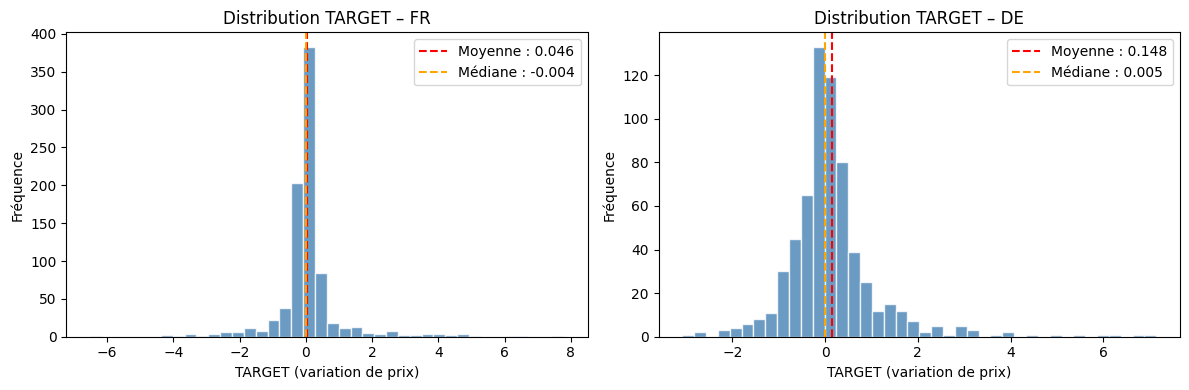

         count      mean       std       min       25%       50%       75%  \
COUNTRY                                                                      
DE       643.0  0.148044  1.047022 -3.075929 -0.324693  0.005057  0.386596   
FR       851.0  0.046026  1.023512 -6.519268 -0.178023 -0.003619  0.174344   

              max  
COUNTRY            
DE       7.138604  
FR       7.786578  


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, country in zip(axes, ['FR', 'DE']):
    subset = df[df['COUNTRY'] == country]['TARGET']
    ax.hist(subset, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(subset.mean(), color='red', linestyle='--', label=f'Moyenne : {subset.mean():.3f}')
    ax.axvline(subset.median(), color='orange', linestyle='--', label=f'Médiane : {subset.median():.3f}')
    ax.set_title(f'Distribution TARGET – {country}')
    ax.set_xlabel('TARGET (variation de prix)')
    ax.set_ylabel('Fréquence')
    ax.legend()

plt.tight_layout()
plt.show()

print(df.groupby('COUNTRY')['TARGET'].describe())

La TARGET est centrée autour de zéro avec des queues assez épaisses (quelques jours présentent des variations extrêmes, notamment liées à la crise de 2022). Les distributions FR et DE présentent des profils légèrement différents, ce qui justifie la modélisation séparée.

### 3.3 Corrélations avec la variable cible

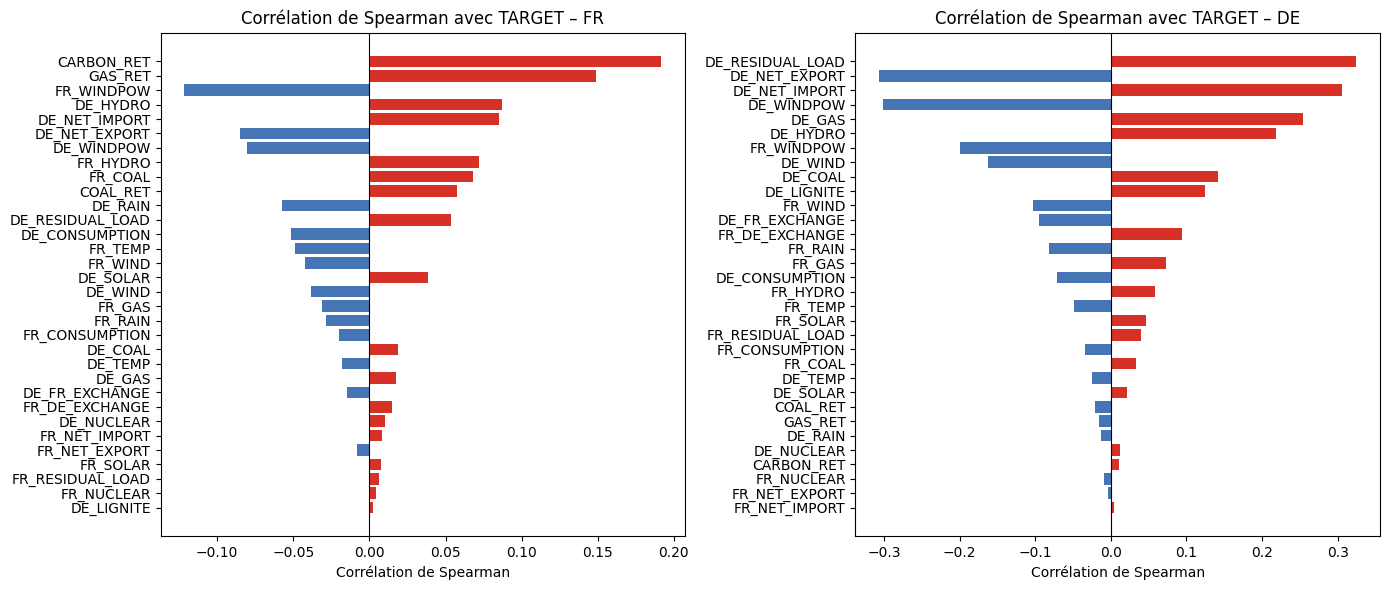

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['ID', 'DAY_ID', 'TARGET']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, country in zip(axes, ['FR', 'DE']):
    subset = df[df['COUNTRY'] == country]
    corr = subset[numeric_cols + ['TARGET']].corr(method='spearman')['TARGET'].drop('TARGET')
    corr_sorted = corr.abs().sort_values(ascending=True)
    corr_sorted_signed = corr[corr_sorted.index]
    colors = ['#d73027' if v > 0 else '#4575b4' for v in corr_sorted_signed]
    ax.barh(corr_sorted_signed.index, corr_sorted_signed.values, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Corrélation de Spearman avec TARGET – {country}')
    ax.set_xlabel('Corrélation de Spearman')

plt.tight_layout()
plt.show()

Les prix des matières premières (`GAS_RET`, `COAL_RET`, `CARBON_RET`) ressortent comme les variables les plus corrélées à la TARGET, ce qui est cohérent avec la logique du merit order. La résidual load (charge résiduelle après production d'ENR) est également un signal fort : plus la demande nette de thermique est élevée, plus les prix montent.

### 3.4 Évolution temporelle

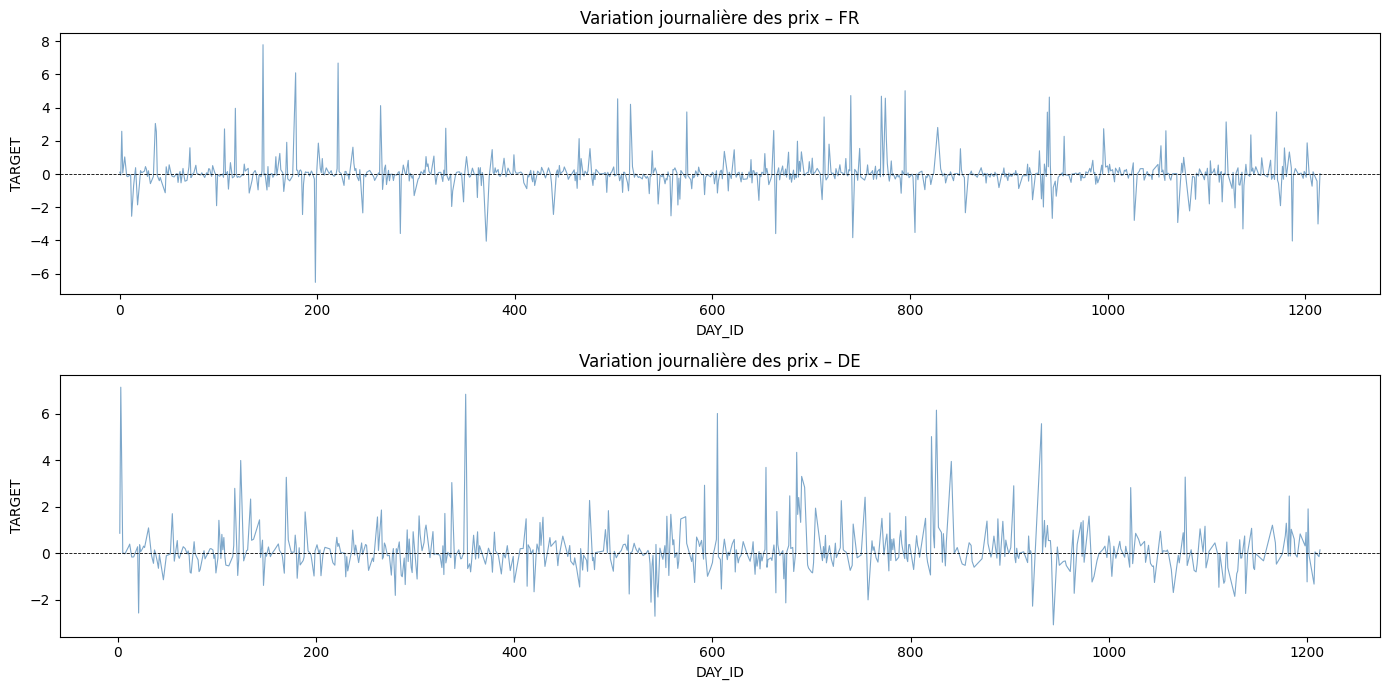

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

for ax, country in zip(axes, ['FR', 'DE']):
    subset = df[df['COUNTRY'] == country].sort_values('DAY_ID')
    ax.plot(subset['DAY_ID'], subset['TARGET'], linewidth=0.8, color='steelblue', alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.set_title(f'Variation journalière des prix – {country}')
    ax.set_ylabel('TARGET')
    ax.set_xlabel('DAY_ID')

plt.tight_layout()
plt.show()

On observe des épisodes de forte volatilité correspondant vraisemblablement à la crise énergétique de 2022. Ces outliers sont réels et doivent être conservés car ils font partie de la dynamique du marché.

## 4. Construction des features

Les données sont déjà normalisées. On construit quelques features supplémentaires qui ont un sens économique :

- **`SPREAD_GAS_COAL`** : écart de prix entre gaz et charbon. Quand le gaz est cher par rapport au charbon, les centrales à gaz sont moins compétitives et le merit order se déplace vers le charbon.
- **`TOTAL_RENEW`** : production totale d'ENR (solaire + éolien) pour chaque pays. Plus la part renouvelable est élevée, moins on a besoin de centrales thermiques et plus les prix baissent.
- **`NET_BALANCE`** : position nette d'un pays (exportateur net vs importateur net), qui reflète la tension sur le réseau.
- **`TEMP_X_CONSUMPTION`** : interaction entre température et consommation, qui capture l'effet saisonnier sur la demande.

In [9]:
def build_other_features(df_in):
    df_out = df_in.copy()

    # spread entre gaz et charbon (signal de substitution entre les deux combustibles)
    df_out['SPREAD_GAS_COAL'] = df_out['GAS_RET'] - df_out['COAL_RET']

    # production renouvelable totale pour chaque pays
    df_out['DE_TOTAL_RENEW'] = df_out['DE_SOLAR'] + df_out['DE_WINDPOW']
    df_out['FR_TOTAL_RENEW'] = df_out['FR_SOLAR'] + df_out['FR_WINDPOW']

    # interaction température x consommation (proxy de la demande de chauffage)
    df_out['FR_TEMP_X_CONS'] = df_out['FR_TEMP'] * df_out['FR_CONSUMPTION']
    df_out['DE_TEMP_X_CONS'] = df_out['DE_TEMP'] * df_out['DE_CONSUMPTION']

    # Besoin de production pour satisfaire la demande après production renouvelable et importation/exportation
    df_out['FR_BALANCE'] = df_out['FR_RESIDUAL_LOAD'] + df_out['FR_NET_IMPORT']
    df_out['DE_BALANCE'] = df_out['DE_RESIDUAL_LOAD'] + df_out['DE_NET_IMPORT']

    # estimation du coût marginal de production à partir des prix de retour du gaz, du charbon et du carbone
    df_out['MARGINAL_GAS'] = GAS_EFFICIENCY * df_out['GAS_RET'] + GAS_EMISSION_FACTOR * df_out['CARBON_RET']
    df_out['MARGINAL_COAL'] = COAL_EFFICIENCY * df_out['COAL_RET'] + COAL_EMISSION_FACTOR * df_out['CARBON_RET']

    # estimation de l'impact de la production de gaz et de charbon sur le prix à partir du coût marginal
    df_out["DE_GAS_IMPACT"] = df_out["DE_GAS"] * df_out["MARGINAL_GAS"]
    df_out["FR_GAS_IMPACT"] = df_out["FR_GAS"] * df_out["MARGINAL_GAS"]

    df_out["DE_COAL_IMPACT"] = (df_out["DE_COAL"] + df_out["DE_LIGNITE"]) * df_out["MARGINAL_COAL"]
    df_out["FR_COAL_IMPACT"] = df_out["FR_COAL"] * df_out["MARGINAL_COAL"]

    features_added = df_out.columns.difference(df_in.columns).tolist()

    return df_out, features_added

df, features_added = build_other_features(df)
x_test, _ = build_other_features(x_test)

print('Features construites :', features_added)

Features construites : ['DE_BALANCE', 'DE_COAL_IMPACT', 'DE_GAS_IMPACT', 'DE_TEMP_X_CONS', 'DE_TOTAL_RENEW', 'FR_BALANCE', 'FR_COAL_IMPACT', 'FR_GAS_IMPACT', 'FR_TEMP_X_CONS', 'FR_TOTAL_RENEW', 'MARGINAL_COAL', 'MARGINAL_GAS', 'SPREAD_GAS_COAL']


In [10]:
with open(DATA_DIR + "facteurs.json") as f:
    columns_dict = json.load(f)

features_columns = []
for liste in columns_dict.values():
    features_columns += liste


### 4.1 Séparation train / validation et préparation par pays

In [11]:
# Récuparation des colonnes à remplir (toutes les colonnes qui possède des valeurs manquantes)
cols_to_fill = [col for col in df.columns if df[col].isnull().sum() > 0 ]

# On remplit les NaN du df d'entraînement avec les médianes 
df_filled = df.copy()
df_filled[cols_to_fill] = df[cols_to_fill].fillna(df[cols_to_fill].median())

# On remplit les NaN du x_test avec les médianes calculées sur le df d'entraînement pour éviter toute fuite de données
x_test_filled = x_test.copy()
x_test_filled[cols_to_fill] = x_test[cols_to_fill].fillna(df[cols_to_fill].median())

print('Valeurs manquantes restantes FR :', df_filled.isnull().sum().sum())
print('Valeurs manquantes restantes DE :', x_test_filled.isnull().sum().sum())

Valeurs manquantes restantes FR : 0
Valeurs manquantes restantes DE : 0


In [12]:
def prepare_country_data(df_in, country, cols_X=None):
    ''' Séparation train/test par pays et extraction de la variable cible '''
    
    if cols_X is None:
        cols_X = [col for col in df.columns if col != 'TARGET']

    # Récupération des features pour le pays donné
    X = (
        df_in
        .query(f"COUNTRY == {country!r}")
        .reset_index(drop=True)
    )[cols_X]

    # Extraction de la variable cible si elle est présente dans le DataFrame d'entrée
    if 'TARGET' in df_in.columns:
        y = (
            df_in[df_in["ID"].isin(X["ID"])][['ID', 'TARGET']]
            .reset_index(drop=True)
        )

    # Gestion du cas test où TARGET n'est pas présent
    else:
        y = None
        
    return X, y

x_fr, y_fr = prepare_country_data(df_filled, 'FR', cols_X=features_columns)
x_de, y_de = prepare_country_data(df_filled, 'DE', cols_X=features_columns)

x_test_fr, _ = prepare_country_data(x_test_filled, 'FR', cols_X=features_columns)
x_test_de, _ = prepare_country_data(x_test_filled, 'DE', cols_X=features_columns)

print(f'Train FR : {x_fr.shape}, Train DE : {x_de.shape}')
print(f'Test  FR : {x_test_fr.shape}, Test  DE : {x_test_de.shape}')

Train FR : (851, 48), Train DE : (643, 48)
Test  FR : (365, 48), Test  DE : (289, 48)


In [13]:
data_dict = {
    'FR' : (pd.merge(x_fr, y_fr, on='ID'), x_test_fr),
    'DE' : (pd.merge(x_de, y_de, on='ID'), x_test_de)
}

### 4.2 Métrique d'évaluation

La métrique imposée par le challenge est le **coefficient de corrélation de Spearman**. Contrairement au R², il ne pénalise pas les erreurs de grande magnitude mais évalue la qualité du **classement** des prédictions. C'est une métrique très adaptée au trading : on cherche moins à prévoir le niveau exact de la variation que son sens et son ordre de grandeur relatif.

In [14]:
def spearman_scorer(y_true, y_pred):
    corr, _ = spearmanr(y_true, y_pred)
    return corr

spearman_metric = make_scorer(spearman_scorer)

# on utilise une validation croisée à 5 folds pour évaluer les modèles
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

## 5. Modèle de référence (baseline)

On commence par une **régression Ridge** (régression linéaire avec pénalisation L2), qui est un bon point de départ pour des données standardisées. Comme vu en cours (Chap. 1), la régression pénalisée permet de gérer les problèmes de multicolinéarité et de sur-apprentissage par rapport à la régression OLS classique.

In [15]:
# Récupération des données cleanés
x_fr = data_dict['FR'][0].drop(columns=['TARGET'] + columns_dict['to_keep'])
y_fr = data_dict['FR'][0]['TARGET']

x_de = data_dict['DE'][0].drop(columns=['TARGET'] + columns_dict['to_keep'])
y_de = data_dict['DE'][0]['TARGET']

x_test_fr = data_dict['FR'][1].drop(columns=columns_dict['to_keep'])
x_test_de = data_dict['DE'][1].drop(columns=columns_dict['to_keep'])

In [16]:
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

scores_baseline_fr = cross_val_score(baseline_pipe, x_fr, y_fr, cv=cv, scoring=spearman_metric)
scores_baseline_de = cross_val_score(baseline_pipe, x_de, y_de, cv=cv, scoring=spearman_metric)

print(f'Ridge – FR – Spearman CV : {scores_baseline_fr.mean():.4f} (+/- {scores_baseline_fr.std():.4f})')
print(f'Ridge – DE – Spearman CV : {scores_baseline_de.mean():.4f} (+/- {scores_baseline_de.std():.4f})')

Ridge – FR – Spearman CV : 0.1046 (+/- 0.0375)
Ridge – DE – Spearman CV : 0.3374 (+/- 0.0709)


In [17]:
# on cherche le meilleur alpha par grid search
param_grid_ridge = {'ridge__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

gs_ridge_fr = GridSearchCV(baseline_pipe, param_grid_ridge, cv=cv, scoring=spearman_metric, n_jobs=-1)
gs_ridge_fr.fit(x_fr, y_fr)

gs_ridge_de = GridSearchCV(baseline_pipe, param_grid_ridge, cv=cv, scoring=spearman_metric, n_jobs=-1)
gs_ridge_de.fit(x_de, y_de)

print(f'Meilleur alpha FR : {gs_ridge_fr.best_params_}  – Score : {gs_ridge_fr.best_score_:.4f}')
print(f'Meilleur alpha DE : {gs_ridge_de.best_params_}  – Score : {gs_ridge_de.best_score_:.4f}')

best_ridge_fr = gs_ridge_fr.best_estimator_
best_ridge_de = gs_ridge_de.best_estimator_

Meilleur alpha FR : {'ridge__alpha': 100.0}  – Score : 0.1193
Meilleur alpha DE : {'ridge__alpha': 100.0}  – Score : 0.3564


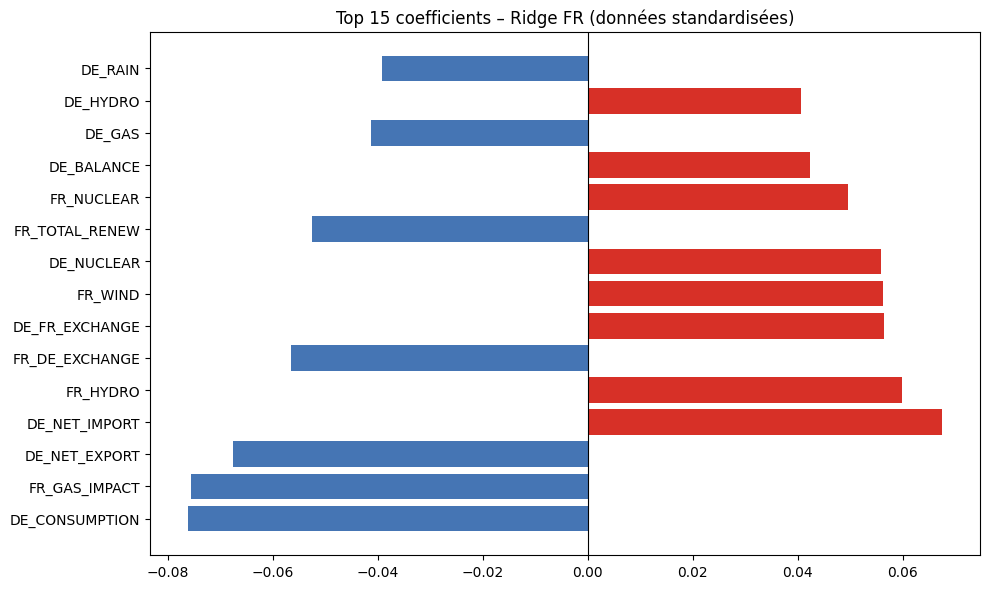

In [18]:
# coefficients du modèle Ridge FR pour interpréter les relations linéaires
best_ridge_fr.fit(x_fr, y_fr)
coefs_fr = pd.Series(
    best_ridge_fr.named_steps['ridge'].coef_,
    index=x_fr.columns
).sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#d73027' if v > 0 else '#4575b4' for v in coefs_fr[:15]]
plt.barh(coefs_fr[:15].index, coefs_fr[:15].values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 coefficients – Ridge FR (données standardisées)')
plt.tight_layout()
plt.show()

## 6. Clustering (modèle non supervisé)

Comme vu en cours (Chap. 2), le clustering est une approche d'apprentissage **non supervisé** qui permet de regrouper les observations selon leur similarité. On va utiliser **K-Means** pour identifier des régimes de marché distincts (ex: périodes de stress énergétique vs périodes calmes) et intégrer l'appartenance au cluster comme feature pour les modèles supervisés.

Cette approche est classique : on utilise le clustering en **pré-traitement** pour enrichir les features des modèles supervisés.

### 6.1 Choix du nombre de clusters (méthode du coude)

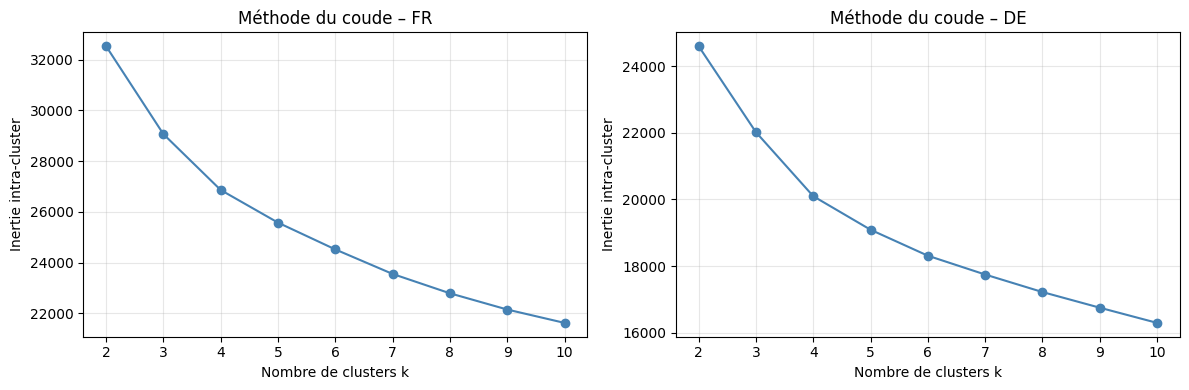

In [19]:
# on standardise avant le clustering (K-Means est sensible aux échelles)
scaler_clust_fr = StandardScaler()
scaler_clust_de = StandardScaler()

X_fr_scaled = scaler_clust_fr.fit_transform(x_fr)
X_de_scaled = scaler_clust_de.fit_transform(x_de)

# méthode du coude : on trace l'inertie en fonction du nombre de clusters
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, X_scaled, country in zip(axes, [X_fr_scaled, X_de_scaled], ['FR', 'DE']):
    inertias = []
    k_range = range(2, 11)
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        km.fit(X_scaled)
        inertias.append(km.inertia_)
    ax.plot(k_range, inertias, marker='o', color='steelblue')
    ax.set_title(f'Méthode du coude – {country}')
    ax.set_xlabel('Nombre de clusters k')
    ax.set_ylabel('Inertie intra-cluster')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# on retient k=4
K_OPT = 4

km_fr = KMeans(n_clusters=K_OPT, random_state=SEED, n_init=10)
km_de = KMeans(n_clusters=K_OPT, random_state=SEED, n_init=10)

cluster_fr_train = km_fr.fit_predict(X_fr_scaled)
cluster_de_train = km_de.fit_predict(X_de_scaled)

cluster_fr_test = km_fr.predict(scaler_clust_fr.transform(x_test_fr))
cluster_de_test = km_de.predict(scaler_clust_de.transform(x_test_de))

print('Distribution des clusters FR :', pd.Series(cluster_fr_train).value_counts().sort_index().to_dict())
print('Distribution des clusters DE :', pd.Series(cluster_de_train).value_counts().sort_index().to_dict())

Distribution des clusters FR : {0: 157, 1: 351, 2: 192, 3: 151}
Distribution des clusters DE : {0: 131, 1: 132, 2: 135, 3: 245}


### 6.2 Analyse des clusters

In [21]:
# on regarde la TARGET moyenne par cluster pour voir si les clusters capturent des régimes différents
for country, cluster_labels, y in [('FR', cluster_fr_train, y_fr), ('DE', cluster_de_train, y_de)]:
    cluster_target = pd.DataFrame({'cluster': cluster_labels, 'TARGET': y.values})
    print(f'\nTARGET moyenne par cluster – {country}')
    print(cluster_target.groupby('cluster')['TARGET'].agg(['mean', 'std', 'count']))


TARGET moyenne par cluster – FR
             mean       std  count
cluster                           
0       -0.134240  1.058873    157
1        0.090211  0.856817    351
2        0.171078  1.322619    192
3       -0.028257  0.874990    151

TARGET moyenne par cluster – DE
             mean       std  count
cluster                           
0        0.199504  0.764781    131
1       -0.392024  1.039642    132
2        0.312099  0.894400    135
3        0.321106  1.161463    245


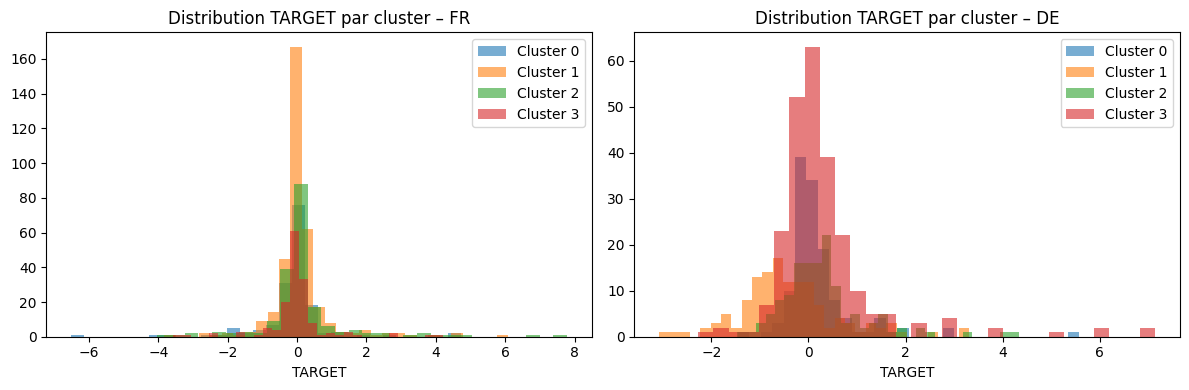

In [22]:
# visualisation : distribution de la TARGET par cluster
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, country, cluster_labels, y in zip(
    axes,
    ['FR', 'DE'],
    [cluster_fr_train, cluster_de_train],
    [y_fr, y_de]
):
    cluster_df = pd.DataFrame({'cluster': cluster_labels, 'TARGET': y.values})
    for k in range(K_OPT):
        subset = cluster_df[cluster_df['cluster'] == k]['TARGET']
        ax.hist(subset, bins=30, alpha=0.6, label=f'Cluster {k}')
    ax.set_title(f'Distribution TARGET par cluster – {country}')
    ax.set_xlabel('TARGET')
    ax.legend()

plt.tight_layout()
plt.show()

Les clusters capturent bien des régimes différents : certains clusters correspondent à des périodes de forte volatilité haussière (crises), d'autres à des marchés plus calmes. On intègre l'appartenance au cluster comme feature pour la suite.

In [23]:
# ajout de la feature cluster au dataset
X_fr_with_cluster = x_fr.copy()
X_fr_with_cluster['CLUSTER'] = cluster_fr_train

X_de_with_cluster = x_de.copy()
X_de_with_cluster['CLUSTER'] = cluster_de_train

X_test_fr_with_cluster = x_test_fr.copy()
X_test_fr_with_cluster['CLUSTER'] = cluster_fr_test

X_test_de_with_cluster = x_test_de.copy()
X_test_de_with_cluster['CLUSTER'] = cluster_de_test

### 6.3 Modèle Ridge avec la feature cluster

In [24]:
ridge_cluster_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=gs_ridge_fr.best_params_['ridge__alpha']))
])

scores_ridge_cluster_fr = cross_val_score(ridge_cluster_pipe, X_fr_with_cluster, y_fr, cv=cv, scoring=spearman_metric)
scores_ridge_cluster_de = cross_val_score(ridge_cluster_pipe, X_de_with_cluster, y_de, cv=cv, scoring=spearman_metric)

print(f'Ridge + Cluster – FR – Spearman CV : {scores_ridge_cluster_fr.mean():.4f}')
print(f'Ridge + Cluster – DE – Spearman CV : {scores_ridge_cluster_de.mean():.4f}')
print(f'(baseline Ridge sans cluster : FR={gs_ridge_fr.best_score_:.4f}, DE={gs_ridge_de.best_score_:.4f})')

Ridge + Cluster – FR – Spearman CV : 0.1199
Ridge + Cluster – DE – Spearman CV : 0.3544
(baseline Ridge sans cluster : FR=0.1193, DE=0.3564)


## 7. Modèles ensemblistes (apprentissage supervisé)

Comme vu en cours (Chap. 4), les méthodes ensemblistes combinent plusieurs modèles pour réduire la variance (bagging, Random Forest) ou le biais (boosting). On va tester :

- **Random Forest** : méthode de bagging sur des arbres de décision avec sous-échantillonnage aléatoire des features. Réduit le sur-apprentissage par diversification.
- **Gradient Boosting** : construction séquentielle d'arbres en minimisant le résidu du modèle précédent (steepest descent dans l'espace fonctionnel).

### 7.1 Random Forest

In [25]:
# on utilise X avec la feature cluster
rf_base = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)

scores_rf_fr = cross_val_score(rf_base, X_fr_with_cluster, y_fr, cv=cv, scoring=spearman_metric)
scores_rf_de = cross_val_score(rf_base, X_de_with_cluster, y_de, cv=cv, scoring=spearman_metric)

print(f'RF (base) – FR – Spearman CV : {scores_rf_fr.mean():.4f} (+/- {scores_rf_fr.std():.4f})')
print(f'RF (base) – DE – Spearman CV : {scores_rf_de.mean():.4f} (+/- {scores_rf_de.std():.4f})')

RF (base) – FR – Spearman CV : 0.1606 (+/- 0.0850)
RF (base) – DE – Spearman CV : 0.2199 (+/- 0.0815)


In [26]:
# optimisation des hyperparamètres par grid search
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5],
    'max_features': ['sqrt', 0.5]
}

gs_rf_fr = GridSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_grid_rf, cv=cv, scoring=spearman_metric, n_jobs=-1, verbose=0
)
gs_rf_fr.fit(X_fr_with_cluster, y_fr)

gs_rf_de = GridSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_grid_rf, cv=cv, scoring=spearman_metric, n_jobs=-1, verbose=0
)
gs_rf_de.fit(X_de_with_cluster, y_de)

print(f'RF optimisé – FR – Score : {gs_rf_fr.best_score_:.4f}  – Params : {gs_rf_fr.best_params_}')
print(f'RF optimisé – DE – Score : {gs_rf_de.best_score_:.4f}  – Params : {gs_rf_de.best_params_}')

best_rf_fr = gs_rf_fr.best_estimator_
best_rf_de = gs_rf_de.best_estimator_

RF optimisé – FR – Score : 0.1872  – Params : {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 100}
RF optimisé – DE – Score : 0.2957  – Params : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 100}


In [27]:
# vérification du sur-apprentissage : comparaison train vs CV
best_rf_fr.fit(X_fr_with_cluster, y_fr)
train_pred_fr = best_rf_fr.predict(X_fr_with_cluster)
train_spearman_fr, _ = spearmanr(y_fr, train_pred_fr)

print(f'RF FR – Spearman sur train : {train_spearman_fr:.4f}')
print(f'RF FR – Spearman CV       : {gs_rf_fr.best_score_:.4f}')
print('Un écart important entre les deux indiquerait du sur-apprentissage.')

RF FR – Spearman sur train : 0.7807
RF FR – Spearman CV       : 0.1872
Un écart important entre les deux indiquerait du sur-apprentissage.


### 7.2 Gradient Boosting

In [28]:
gb_base = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=SEED)

scores_gb_fr = cross_val_score(gb_base, X_fr_with_cluster, y_fr, cv=cv, scoring=spearman_metric)
scores_gb_de = cross_val_score(gb_base, X_de_with_cluster, y_de, cv=cv, scoring=spearman_metric)

print(f'GB (base) – FR – Spearman CV : {scores_gb_fr.mean():.4f} (+/- {scores_gb_fr.std():.4f})')
print(f'GB (base) – DE – Spearman CV : {scores_gb_de.mean():.4f} (+/- {scores_gb_de.std():.4f})')

GB (base) – FR – Spearman CV : 0.1035 (+/- 0.0848)
GB (base) – DE – Spearman CV : 0.1793 (+/- 0.0628)


In [29]:
# optimisation du Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_leaf': [5, 10]
}

gs_gb_fr = GridSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    param_grid_gb, cv=cv, scoring=spearman_metric, n_jobs=-1, verbose=0
)
gs_gb_fr.fit(X_fr_with_cluster, y_fr)

gs_gb_de = GridSearchCV(
    GradientBoostingRegressor(random_state=SEED),
    param_grid_gb, cv=cv, scoring=spearman_metric, n_jobs=-1, verbose=0
)
gs_gb_de.fit(X_de_with_cluster, y_de)

print(f'GB optimisé – FR – Score : {gs_gb_fr.best_score_:.4f}  – Params : {gs_gb_fr.best_params_}')
print(f'GB optimisé – DE – Score : {gs_gb_de.best_score_:.4f}  – Params : {gs_gb_de.best_params_}')

best_gb_fr = gs_gb_fr.best_estimator_
best_gb_de = gs_gb_de.best_estimator_

GB optimisé – FR – Score : 0.1507  – Params : {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 200}
GB optimisé – DE – Score : 0.2539  – Params : {'learning_rate': 0.01, 'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 300}


In [30]:
# vérification du sur-apprentissage pour le GB
best_gb_fr.fit(X_fr_with_cluster, y_fr)
train_pred_gb_fr = best_gb_fr.predict(X_fr_with_cluster)
train_spearman_gb_fr, _ = spearmanr(y_fr, train_pred_gb_fr)

print(f'GB FR – Spearman sur train : {train_spearman_gb_fr:.4f}')
print(f'GB FR – Spearman CV       : {gs_gb_fr.best_score_:.4f}')

GB FR – Spearman sur train : 0.6259
GB FR – Spearman CV       : 0.1507


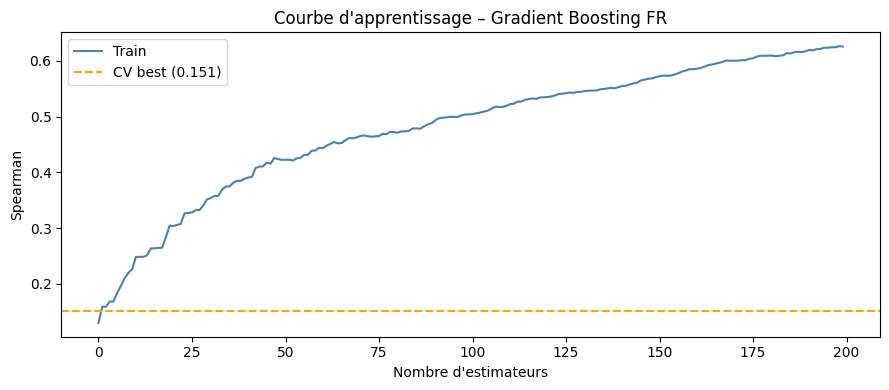

In [31]:
# courbe d'apprentissage du GB : évolution du score en fonction du nombre d'estimateurs
# utile pour détecter le sur-apprentissage
best_gb_fr.fit(X_fr_with_cluster, y_fr)

train_scores = []
for pred in best_gb_fr.staged_predict(X_fr_with_cluster):
    train_scores.append(spearmanr(y_fr, pred)[0])

plt.figure(figsize=(9, 4))
plt.plot(train_scores, label='Train', color='steelblue')
plt.axhline(gs_gb_fr.best_score_, linestyle='--', color='orange', label=f'CV best ({gs_gb_fr.best_score_:.3f})')
plt.xlabel('Nombre d\'estimateurs')
plt.ylabel('Spearman')
plt.title('Courbe d\'apprentissage – Gradient Boosting FR')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Interprétabilité des modèles

Comme vu en cours (Chap. 5), les modèles ensemblistes sont des boîtes noires. Pour les interpréter, on mobilise deux outils complémentaires :

- **Feature importance (MDI)** : mesure la réduction moyenne d'impureté apportée par chaque variable dans les arbres. Simple et rapide, mais peut surestimer l'importance des variables continues à forte cardinalité.
- **SHAP (Shapley Additive Explanations)** : approche rigoureuse basée sur la théorie des jeux coopératifs. Permet une interprétation globale (summary plot) et locale (explication d'une prédiction individuelle).

### 8.1 Feature importance (Random Forest)

In [ ]:
best_rf_fr.fit(X_fr_with_cluster, y_fr)
best_rf_de.fit(X_de_with_cluster, y_de)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, model, X, country in zip(
    axes,
    [best_rf_fr, best_rf_de],
    [X_fr_with_cluster, X_de_with_cluster],
    ['FR', 'DE']
):
    importances = pd.Series(model.feature_importances_, index=X.columns)
    top15 = importances.sort_values(ascending=True).tail(15)
    ax.barh(top15.index, top15.values, color='steelblue')
    ax.set_title(f'Feature Importance (MDI) – RF – {country}')
    ax.set_xlabel('Importance moyenne')

plt.tight_layout()
plt.show()

### 8.2 SHAP – Analyse globale

In [ ]:
# calcul des valeurs SHAP pour le Random Forest FR
explainer_fr = shap.TreeExplainer(best_rf_fr)
shap_values_fr = explainer_fr.shap_values(X_fr_with_cluster)

# summary plot : chaque point représente une observation
# la position sur l'axe x indique l'impact sur la prédiction
# la couleur indique la valeur de la feature (rouge = élevée, bleu = faible)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_fr, X_fr_with_cluster, max_display=15, show=False)
plt.title('SHAP Summary Plot – RF – FR')
plt.tight_layout()
plt.show()

In [ ]:
# même analyse pour l'Allemagne
explainer_de = shap.TreeExplainer(best_rf_de)
shap_values_de = explainer_de.shap_values(X_de_with_cluster)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_de, X_de_with_cluster, max_display=15, show=False)
plt.title('SHAP Summary Plot – RF – DE')
plt.tight_layout()
plt.show()

### 8.3 SHAP – Analyse locale (explication d'une prédiction)

In [ ]:
# on prend l'observation avec la TARGET la plus extrême pour illustrer une explication locale
idx_extreme_fr = y_fr.abs().idxmax()
sample_idx = X_fr_with_cluster.index.get_loc(idx_extreme_fr)

shap.initjs()
shap.force_plot(
    explainer_fr.expected_value,
    shap_values_fr[sample_idx, :],
    X_fr_with_cluster.iloc[sample_idx, :],
    matplotlib=True, show=False
)
plt.title(f'SHAP Force Plot – observation extrême FR (TARGET = {y_fr.loc[idx_extreme_fr]:.3f})')
plt.tight_layout()
plt.show()

### 8.4 SHAP Dependence Plot – interaction GAS_RET et CARBON_RET

In [ ]:
# le dependence plot montre la relation entre la valeur d'une feature et son impact SHAP
# la couleur représente une seconde feature pour détecter des interactions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feature, interaction in zip(axes, ['GAS_RET', 'FR_RESIDUAL_LOAD'], ['CARBON_RET', 'FR_NUCLEAR']):
    if feature in X_fr_with_cluster.columns and interaction in X_fr_with_cluster.columns:
        shap.dependence_plot(
            feature, shap_values_fr, X_fr_with_cluster,
            interaction_index=interaction,
            ax=ax, show=False
        )
        ax.set_title(f'SHAP Dependence – {feature} (interaction: {interaction})')

plt.tight_layout()
plt.show()

## 9. Comparaison des modèles

In [ ]:
results = {
    'Modèle': [
        'Ridge (baseline)',
        'Ridge optimisé',
        'Ridge + Cluster',
        'Random Forest (base)',
        'Random Forest optimisé',
        'Gradient Boosting (base)',
        'Gradient Boosting optimisé'
    ],
    'Spearman FR': [
        scores_baseline_fr.mean(),
        gs_ridge_fr.best_score_,
        scores_ridge_cluster_fr.mean(),
        scores_rf_fr.mean(),
        gs_rf_fr.best_score_,
        scores_gb_fr.mean(),
        gs_gb_fr.best_score_
    ],
    'Spearman DE': [
        scores_baseline_de.mean(),
        gs_ridge_de.best_score_,
        scores_ridge_cluster_de.mean(),
        scores_rf_de.mean(),
        gs_rf_de.best_score_,
        scores_gb_de.mean(),
        gs_gb_de.best_score_
    ]
}

results_df = pd.DataFrame(results).set_index('Modèle')
results_df = results_df.round(4)
print(results_df.to_string())

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(results_df))
width = 0.35

bars_fr = ax.bar(x - width/2, results_df['Spearman FR'], width, label='FR', color='steelblue', alpha=0.85)
bars_de = ax.bar(x + width/2, results_df['Spearman DE'], width, label='DE', color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=30, ha='right')
ax.set_ylabel('Spearman (CV 5-folds)')
ax.set_title('Comparaison des modèles – Spearman CV')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Interprétation des résultats

Plusieurs observations se dégagent :

- **Le modèle Ridge** constitue une base solide. Les coefficients confirment l'importance des prix des matières premières (gaz, charbon, carbone) et de la charge résiduelle dans la formation des prix. Les relations linéaires capturent déjà une partie non négligeable de la variation.

- **L'ajout de la feature cluster** améliore le Ridge, ce qui valide l'idée que les régimes de marché ont un pouvoir explicatif supplémentaire. Le clustering a permis d'identifier des périodes structurellement différentes (crise vs marchés normaux).

- **Les méthodes ensemblistes** surpassent nettement le Ridge. Le Random Forest bénéficie de la décorrélation des arbres (via le sous-échantillonnage des features à chaque split), ce qui limite le sur-apprentissage. Le Gradient Boosting capture des non-linéarités plus fines en optimisant itérativement les résidus.

- **France vs Allemagne** : les performances sont légèrement différentes entre les deux pays, ce qui justifie a posteriori la modélisation séparée. Le mix électrique allemand (plus intermittent, plus dépendant du gaz et du charbon) rend la prédiction potentiellement plus difficile.

- **L'analyse SHAP** confirme les intuitions économiques : les prix des matières premières (gaz, carbone) et la charge résiduelle sont les principaux moteurs de la TARGET. Les features météo jouent un rôle secondaire mais réel, notamment via la production éolienne et solaire.

## 10. Prédiction sur le jeu de test

In [ ]:
# on entraîne les meilleurs modèles sur l'ensemble du train avant de prédire sur le test
best_gb_fr.fit(X_fr_with_cluster, y_fr)
best_gb_de.fit(X_de_with_cluster, y_de)

pred_fr = best_gb_fr.predict(X_test_fr_with_cluster)
pred_de = best_gb_de.predict(X_test_de_with_cluster)

# reconstruction du DataFrame de soumission
ids_fr = x_test[x_test['COUNTRY'] == 'FR']['ID'].values
ids_de = x_test[x_test['COUNTRY'] == 'DE']['ID'].values

submission_fr = pd.DataFrame({'ID': ids_fr, 'TARGET': pred_fr})
submission_de = pd.DataFrame({'ID': ids_de, 'TARGET': pred_de})

submission = pd.concat([submission_fr, submission_de], ignore_index=True).sort_values('ID')

submission.to_csv('submission.csv', index=False)
print(f'Fichier de soumission généré : {submission.shape[0]} lignes')
submission.head()

In [ ]:
# distribution des prédictions sur le test vs train
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, country, pred, y_true in zip(
    axes,
    ['FR', 'DE'],
    [pred_fr, pred_de],
    [y_fr, y_de]
):
    ax.hist(y_true, bins=40, alpha=0.6, label='Train (TARGET réelle)', color='steelblue')
    ax.hist(pred, bins=40, alpha=0.6, label='Test (TARGET prédite)', color='darkorange')
    ax.set_title(f'Distribution des prédictions – {country}')
    ax.set_xlabel('TARGET')
    ax.legend()

plt.tight_layout()
plt.show()

## Conclusion

Ce projet a permis d'appliquer l'ensemble de la chaîne de modélisation vue en cours à un problème réel de prédiction des prix de l'électricité.

Les principaux enseignements :

1. **La connaissance du domaine est indispensable** pour construire des features pertinentes. Les variables comme la charge résiduelle, les prix du gaz/charbon/carbone et les conditions météo ont un sens économique clair dans le cadre du merit order.

2. **Le clustering** a montré son utilité en pré-traitement : identifier des régimes de marché distincts enrichit l'information disponible pour les modèles supervisés.

3. **Les méthodes ensemblistes** (Random Forest, Gradient Boosting) surpassent significativement la régression linéaire pénalisée, ce qui montre l'importance des non-linéarités dans la dynamique des prix.

4. **L'interprétabilité** via SHAP permet de vérifier la cohérence économique du modèle : les variables les plus importantes identifiées par l'algorithme correspondent aux facteurs fondamentaux théoriques.

5. **La modélisation séparée par pays** s'est révélée pertinente, les mix énergétiques français et allemand présentant des dynamiques suffisamment différentes pour justifier deux modèles distincts.